Decision Tree Accuracy: 0.963
Random Forest Accuracy: 1.0

Random Forest Classification Report:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54


Impurity-Based Feature Importance (MDI):

color_intensity                 0.164947
flavanoids                      0.154674
alcohol                         0.146022
proline                         0.142511
od280/od315_of_diluted_wines    0.094885
hue                             0.094361
total_phenols                   0.052453
malic_acid                      0.035982
magnesium                       0.033691
alcalinity_of_ash               0.030471
proanthocyanins                 0.022934
nonflavanoid_phenols        

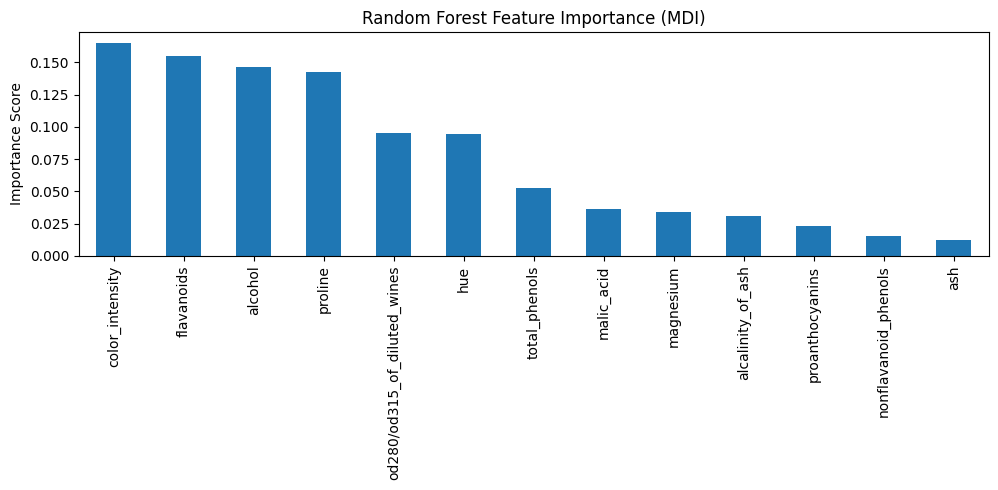

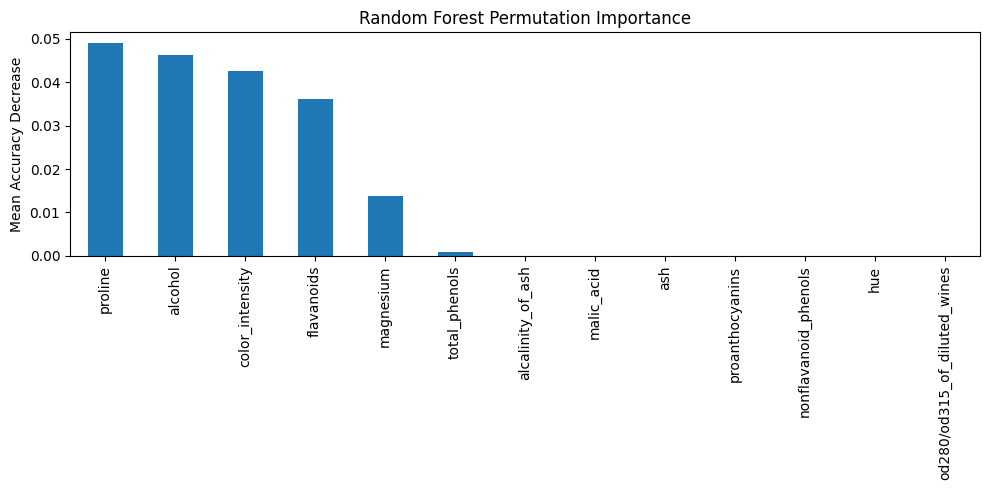

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, classification_report

# Load dataset
wine = load_wine()
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = wine.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Single decision tree baseline
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)
tree_acc = accuracy_score(y_test, tree_pred)

# Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)

print("Decision Tree Accuracy:", round(tree_acc, 4))
print("Random Forest Accuracy:", round(rf_acc, 4))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, rf_pred, target_names=wine.target_names))

# Impurity-based feature importance
mdi_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("\nImpurity-Based Feature Importance (MDI):\n")
print(mdi_importance)

# Permutation importance
perm_result = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=20,
    random_state=42,
    scoring="accuracy"
)

perm_importance = pd.Series(
    perm_result.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print("\nPermutation Feature Importance:\n")
print(perm_importance)

# Plot impurity-based feature importance
plt.figure(figsize=(10, 5))
mdi_importance.plot(kind="bar")
plt.title("Random Forest Feature Importance (MDI)")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

# Plot permutation importance
plt.figure(figsize=(10, 5))
perm_importance.plot(kind="bar")
plt.title("Random Forest Permutation Importance")
plt.ylabel("Mean Accuracy Decrease")
plt.tight_layout()
plt.show()